# Step 3-2. XGBoost Walk-Forward (GKX 2020)

**파이프라인**
1. `monthly_panel.csv` 로드
2. 피처 정규화: 주식 → 횡단면 rank [-1,1] / 매크로 → rolling z-score
3. Walk-forward expanding window (연단위 슬라이딩)
4. XGBoost 훈련 + OOS 예측
5. 평가: R²_OOS, IC, Feature Importance
6. Q & Omega 생성 (Black-Litterman용)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
import warnings
import pickle
warnings.filterwarnings('ignore')

import xgboost as xgb
from scipy.stats import spearmanr

# 한글 폰트
for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR   = Path('data')
OUTPUT_DIR = Path('outputs/step2_xgb')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('환경 초기화 완료')

환경 초기화 완료


---
## Section 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA_DIR / 'monthly_panel.csv', index_col='date', parse_dates=True)
df = df.sort_index()

print(f'패널 : {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'기간 : {df.index.min().date()} ~ {df.index.max().date()}')
print(f'종목 : {df["ticker"].nunique()}개')
print(f'날짜 : {df.index.nunique()}개')
print()
print('NaN 비율 (상위 10):')
print(df.isna().mean().sort_values(ascending=False).head(10).round(4))

패널 : 93,113행 × 69열
기간 : 2004-01-31 ~ 2025-11-30
종목 : 494개
날짜 : 263개

NaN 비율 (상위 10):
hy_spread           0.8377
indmom              0.0780
ivol_63d            0.0496
idiovol_21d         0.0430
chmom               0.0397
vol_252d            0.0397
beta_252d           0.0397
mom_12m             0.0397
mom_12m_skip_1m     0.0397
rate_sensitivity    0.0389
dtype: float64


---
## Section 2. 피처 정의 & 정규화

- **주식 피처**: 날짜별 횡단면 rank → [-1, 1]  (GKX 방식)
- **매크로 피처**: rolling z-score (252일, lookahead 없음)

In [3]:
META   = ['ticker', 'gics_sector']
TARGET = 'fwd_excess_ret_1m'

# 주식 피처 (횡단면 rank 정규화)
_STOCK_CANDIDATE = [
    'mom_1w', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
    'mom_12m_skip_1m', 'chmom', 'indmom',
    'vol_20d', 'vol_60d', 'vol_252d',
    'beta_252d', 'idiovol_21d', 'ivol_63d',
    'dollar_vol_21d', 'amihud_21d', 'log_mcap',
    'high52w_ratio', 'low52w_ratio', 'maxret_21d',
    'ma_gap_20_60', 'rsi_14', 'bb_pct',
    'intraday_range', 'vol_surge', 'autocorr_21d',
    'sharpe_21d', 'sharpe_63d', 'sortino_63d', 'ir_63d',
    'skew_63d', 'kurt_63d', 'mdd_252d',
    'rate_sensitivity', 'avg_corr',
]

# 매크로 피처 (rolling z-score)
_MACRO_CANDIDATE = [
    'wti_crude', 'gold', 'silver', 'vix', 'dxy',
    'skew_idx', 'copper', 't10y2y', 'icsa', 'sahm',
    'cpi', 'unrate',
]

# 실제 컬럼에 있는 것만 사용 (재실행 시 hy_spread 없는 버전도 호환)
STOCK_FEATS = [c for c in _STOCK_CANDIDATE if c in df.columns]
MACRO_FEATS = [c for c in _MACRO_CANDIDATE if c in df.columns]
ALL_FEATS   = STOCK_FEATS + MACRO_FEATS

print(f'주식 피처 : {len(STOCK_FEATS)}개')
print(f'매크로 피처: {len(MACRO_FEATS)}개')
print(f'전체 피처  : {len(ALL_FEATS)}개')

주식 피처 : 35개
매크로 피처: 12개
전체 피처  : 47개


In [4]:
def cs_rank_norm(group: pd.DataFrame, cols: list) -> pd.DataFrame:
    """횡단면 rank → [-1, 1]"""
    out = group.copy()
    for c in cols:
        if c not in out.columns:
            continue
        s     = out[c]
        valid = s.notna()
        n     = valid.sum()
        if n < 2:
            continue
        ranked = s[valid].rank(method='average')
        out.loc[valid, c] = 2 * (ranked - 1) / (n - 1) - 1
    return out


def rolling_zscore(series: pd.Series, window: int = 252, min_periods: int = 63) -> pd.Series:
    """rolling z-score (lookahead 없음)"""
    mu  = series.rolling(window, min_periods=min_periods).mean()
    sig = series.rolling(window, min_periods=min_periods).std()
    return (series - mu) / sig.replace(0, np.nan)


# 매크로: 날짜당 하나의 값 → 대표 시계열 추출 후 rolling z-score
macro_ts = df[~df.index.duplicated(keep='first')][MACRO_FEATS].sort_index()
macro_z  = macro_ts.apply(rolling_zscore)

# 작업 데이터프레임 구성
df_work = df[META + [TARGET] + STOCK_FEATS].copy()
for col in MACRO_FEATS:
    df_work[col] = df_work.index.map(macro_z[col])

# 주식 피처: 날짜별 횡단면 rank → [-1, 1]
print('횡단면 rank 정규화 중...')
df_norm = (
    df_work
    .groupby(level='date', group_keys=False)
    .apply(lambda g: cs_rank_norm(g, STOCK_FEATS))
)

nan_pct = df_norm[ALL_FEATS].isna().mean().sort_values(ascending=False)
print(f'\n정규화 완료: {df_norm.shape}')
print('NaN 비율 (상위 10):')
print(nan_pct.head(10).round(4))

횡단면 rank 정규화 중...

정규화 완료: (93113, 50)
NaN 비율 (상위 10):
unrate      0.1896
cpi         0.1896
sahm        0.1896
t10y2y      0.1864
silver      0.1864
gold        0.1864
icsa        0.1864
dxy         0.1864
copper      0.1864
skew_idx    0.1864
dtype: float64


In [5]:
df_norm[11100:11110]

,ticker,gics_sector,fwd_excess_ret_1m,mom_1w,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_skip_1m,chmom,...,silver,vix,dxy,skew_idx,copper,t10y2y,icsa,sahm,cpi,unrate
date,,,,,,,,,,,,,,,,,,,,,
2007-05-31,GEN,Information Technology,0.006296,0.437722,0.886121,0.665480,-0.772242,0.135714,-0.357143,-0.942857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,FDX,Industrials,-0.009121,0.857651,0.352313,-0.800712,-0.786477,-0.750000,-0.792857,-0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,WYNN,Consumer Discretionary,-0.075193,-0.928826,-0.935943,-0.693950,-0.224199,0.685714,0.842857,-0.878571,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,DVN,Energy,0.017287,-0.736655,0.330961,0.615658,-0.096085,0.442857,0.364286,-0.550000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,AMD,Information Technology,-0.002106,-0.985765,0.366548,-0.857651,-1.000000,-1.000000,-1.000000,-0.285714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,RSG,Industrials,0.011288,0.722420,0.758007,0.046263,-0.124555,-0.471429,-0.671429,0.314286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,TPR,Consumer Discretionary,-0.081506,0.800712,0.572954,-0.096085,0.494662,0.907143,0.892857,-0.800000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,CVS,Health Care,-0.058438,0.209964,0.608541,0.864769,0.928826,0.507143,0.335714,0.950000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,APA,Energy,0.006194,0.644128,0.822064,0.679715,0.615658,0.064286,-0.321429,0.714286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Section 3. Walk-Forward Fold 생성

- **방식**: Expanding window (GKX) — 훈련 데이터가 매년 1년치씩 누적
- **최소 훈련 기간**: 3년
- **테스트 기간**: 연단위 슬라이딩
- **GAP**: train 종료 ~ test 시작 사이 21일 (overlapping label 방지)

In [6]:
TRAIN_START  = '2005-01-01'   # 252일 burn-in 이후
MIN_TRAIN_YR = 3              # 최소 학습 기간 (년)
GAP_DAYS     = 21             # label overlap 방지 gap

all_dates = sorted(df_norm.index.unique())
all_dates = [d for d in all_dates if d >= pd.Timestamp(TRAIN_START)]
year_set  = sorted(set(d.year for d in all_dates))

folds = []
for yr in year_set:
    test_start   = pd.Timestamp(f'{yr}-01-01')
    test_end     = pd.Timestamp(f'{yr}-12-31')
    train_cutoff = test_start - pd.Timedelta(days=GAP_DAYS)

    train_dates = [d for d in all_dates if d < train_cutoff]
    test_dates  = [d for d in all_dates if test_start <= d <= test_end]

    if len(train_dates) < MIN_TRAIN_YR * 12 or not test_dates:
        continue

    folds.append({'year': yr, 'train': train_dates, 'test': test_dates})

print(f'Walk-forward fold: {len(folds)}개')
print('  {:>6}  {:>12}  {:>9}'.format('연도', 'train 기간', 'test 기간'))
for f in folds:
    tr_start = min(f['train']).strftime('%Y-%m')
    tr_end   = max(f['train']).strftime('%Y-%m')
    print(f"  {f['year']:>6}  {tr_start}~{tr_end}  ({len(f['test'])}기간)")

Walk-forward fold: 17개
      연도      train 기간    test 기간
    2009  2005-01~2008-11  (12기간)
    2010  2005-01~2009-11  (12기간)
    2011  2005-01~2010-11  (12기간)
    2012  2005-01~2011-11  (12기간)
    2013  2005-01~2012-11  (12기간)
    2014  2005-01~2013-11  (12기간)
    2015  2005-01~2014-11  (12기간)
    2016  2005-01~2015-11  (12기간)
    2017  2005-01~2016-11  (12기간)
    2018  2005-01~2017-11  (12기간)
    2019  2005-01~2018-11  (12기간)
    2020  2005-01~2019-11  (12기간)
    2021  2005-01~2020-11  (12기간)
    2022  2005-01~2021-11  (12기간)
    2023  2005-01~2022-11  (12기간)
    2024  2005-01~2023-11  (12기간)
    2025  2005-01~2024-11  (11기간)


---
## Section 4. XGBoost Walk-Forward 훈련

In [ ]:
XGB_PARAMS = dict(
    objective         = 'reg:pseudohubererror',   # GKX: Huber loss (fat tail robust)
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.5,
    min_child_weight  = 20,
    reg_lambda        = 1.0,
    reg_alpha         = 0.1,
    tree_method       = 'hist',
    early_stopping_rounds = 50,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

oos_parts    = []
feat_imp_sum = pd.Series(0.0, index=ALL_FEATS)
fold_metrics = []

for fold in folds:
    yr = fold['year']

    tr = df_norm[df_norm.index.isin(fold['train'])].dropna(subset=ALL_FEATS + [TARGET])
    te = df_norm[df_norm.index.isin(fold['test'])].dropna(subset=ALL_FEATS + [TARGET])

    unique_tr = sorted(tr.index.unique())
    if len(tr) < 300 or len(unique_tr) < 13 or len(te) == 0:
        print(f'  {yr}: 데이터 부족 (train={len(tr)}, dates={len(unique_tr)}, test={len(te)}) → 스킵')
        continue

    # validation: train 마지막 12개 날짜 (early stopping용)
    val_cutoff = unique_tr[-12]
    val_mask   = tr.index >= val_cutoff

    X_tr,  y_tr  = tr[~val_mask][ALL_FEATS].values, tr[~val_mask][TARGET].values
    X_val, y_val = tr[val_mask][ALL_FEATS].values,  tr[val_mask][TARGET].values
    X_te,  y_te  = te[ALL_FEATS].values,            te[TARGET].values

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    y_pred = model.predict(X_te)

    # feature importance 누적
    feat_imp_sum += pd.Series(model.feature_importances_, index=ALL_FEATS)

    # OOS 저장
    te_out         = te[META + [TARGET]].copy()
    te_out['pred'] = y_pred
    oos_parts.append(te_out)

    # fold 지표
    ic     = spearmanr(y_te, y_pred)[0]
    ss_res = ((y_te - y_pred) ** 2).sum()
    ss_tot = (y_te ** 2).sum()
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fold_metrics.append({'year': yr, 'IC': ic, 'R2_OOS': r2, 'n': len(te)})
    print(f'  {yr}: IC={ic:+.4f}  R²_OOS={r2:+.4f}  n={len(te):,}')

oos_df     = pd.concat(oos_parts).sort_index()
metrics_df = pd.DataFrame(fold_metrics).set_index('year')

print(f'OOS 전체: {oos_df.shape[0]:,}행')

  2009: 데이터 부족 (train=0, dates=0, test=2395) → 스킵
  2010: 데이터 부족 (train=2128, dates=8, test=2674) → 스킵
  2011: IC=-0.1487  R²_OOS=-0.3201  n=3,270
  2012: IC=+0.1488  R²_OOS=+0.0309  n=3,366
  2013: IC=-0.1284  R²_OOS=+0.0799  n=3,496
  2014: IC=+0.0865  R²_OOS=+0.0642  n=3,571
  2015: IC=+0.2658  R²_OOS=-0.0530  n=3,671
  2016: IC=+0.2164  R²_OOS=+0.1404  n=3,535
  2017: IC=+0.0992  R²_OOS=+0.0685  n=3,963
  2018: IC=+0.3010  R²_OOS=-0.0342  n=4,447
  2019: IC=+0.2594  R²_OOS=+0.0479  n=4,674
  2020: IC=+0.0950  R²_OOS=+0.0153  n=4,963
  2021: IC=+nan  R²_OOS=+0.0596  n=5,131
  2022: IC=-0.0542  R²_OOS=-0.0011  n=5,267
  2023: IC=-0.0030  R²_OOS=-0.0317  n=5,435
  2024: IC=+0.0694  R²_OOS=+0.0094  n=5,606
  2025: IC=-0.0331  R²_OOS=-0.0133  n=5,330
OOS 전체: 65,725행


---
## Section 5. 성과 평가

- **R²_OOS**: GKX 기준 (분모 = 0, 나이브 예측 대비)
- **IC**: Spearman rank 상관계수 (예측 vs 실제)
- **ICIR**: IC / IC_std

In [8]:
# IC 시계열 (날짜별) — 그래프용으로만 사용
ic_ts = (
    oos_df.groupby(level='date')
    .apply(lambda g: spearmanr(g[TARGET], g['pred'])[0] if len(g) >= 5 else np.nan)
    .rename('IC')
)

# 전체 R²_OOS (pooled)
y_all = oos_df[TARGET].values
p_all = oos_df['pred'].values
r2_total = 1 - ((y_all - p_all) ** 2).sum() / (y_all ** 2).sum()

# fold 단위 IC 요약 (신뢰할 수 있는 지표)
fold_ic = metrics_df['IC']
ic_fold_mean  = fold_ic.mean()
ic_fold_std   = fold_ic.std()
ic_fold_icir  = ic_fold_mean / ic_fold_std
ic_fold_pos   = (fold_ic > 0).mean()

print('=== OOS 성과 요약 ===')
print(f'R²_OOS (전체 pooled) : {r2_total:+.4f}  ({r2_total*100:+.2f}%)')
print()
print('--- Fold 단위 IC (연도별, 신뢰 가능) ---')
print(f'IC 평균              : {ic_fold_mean:+.4f}')
print(f'IC std               : {ic_fold_std:.4f}')
print(f'ICIR                 : {ic_fold_icir:+.4f}')
print(f'IC > 0 비율          : {ic_fold_pos:.1%}  ({int(ic_fold_pos*len(fold_ic))}/{len(fold_ic)}년)')
print()
print(metrics_df.round(4))


=== OOS 성과 요약 ===
R²_OOS (전체 pooled) : -0.0001  (-0.01%)

--- Fold 단위 IC (연도별, 신뢰 가능) ---
IC 평균              : +0.0839
IC std               : 0.1449
ICIR                 : +0.5789
IC > 0 비율          : 60.0%  (9/15년)

          IC  R2_OOS     n
year                      
2011 -0.1487 -0.3201  3270
2012  0.1488  0.0309  3366
2013 -0.1284  0.0799  3496
2014  0.0865  0.0642  3571
2015  0.2658 -0.0530  3671
2016  0.2164  0.1404  3535
2017  0.0992  0.0685  3963
2018  0.3010 -0.0342  4447
2019  0.2594  0.0479  4674
2020  0.0950  0.0153  4963
2021     NaN  0.0596  5131
2022 -0.0542 -0.0011  5267
2023 -0.0030 -0.0317  5435
2024  0.0694  0.0094  5606
2025 -0.0331 -0.0133  5330


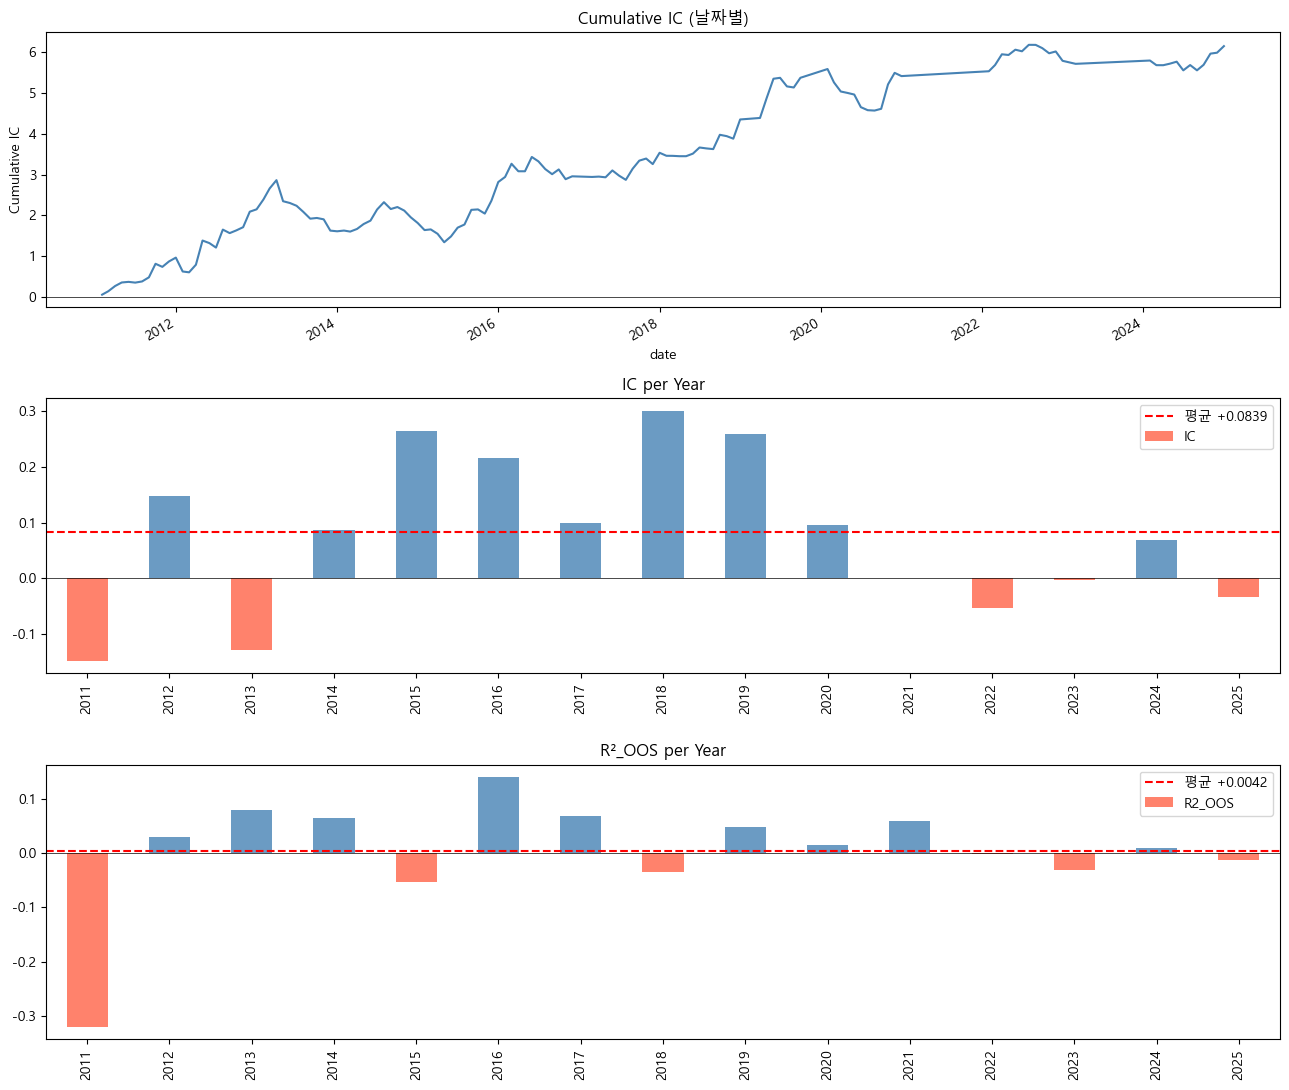

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# 누적 IC
ic_ts.dropna().cumsum().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Cumulative IC (날짜별)')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('Cumulative IC')

# 연도별 IC
colors = ['steelblue' if v >= 0 else 'tomato' for v in metrics_df['IC']]
metrics_df['IC'].plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('IC per Year')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axhline(metrics_df['IC'].mean(), color='red', linestyle='--',
                label=f'평균 {metrics_df["IC"].mean():+.4f}')
axes[1].legend()
axes[1].set_xlabel('')

# 연도별 R²_OOS
colors2 = ['steelblue' if v >= 0 else 'tomato' for v in metrics_df['R2_OOS']]
metrics_df['R2_OOS'].plot(kind='bar', ax=axes[2], color=colors2, alpha=0.8)
axes[2].set_title('R²_OOS per Year')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].axhline(metrics_df['R2_OOS'].mean(), color='red', linestyle='--',
                label=f'평균 {metrics_df["R2_OOS"].mean():+.4f}')
axes[2].legend()
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_IC_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

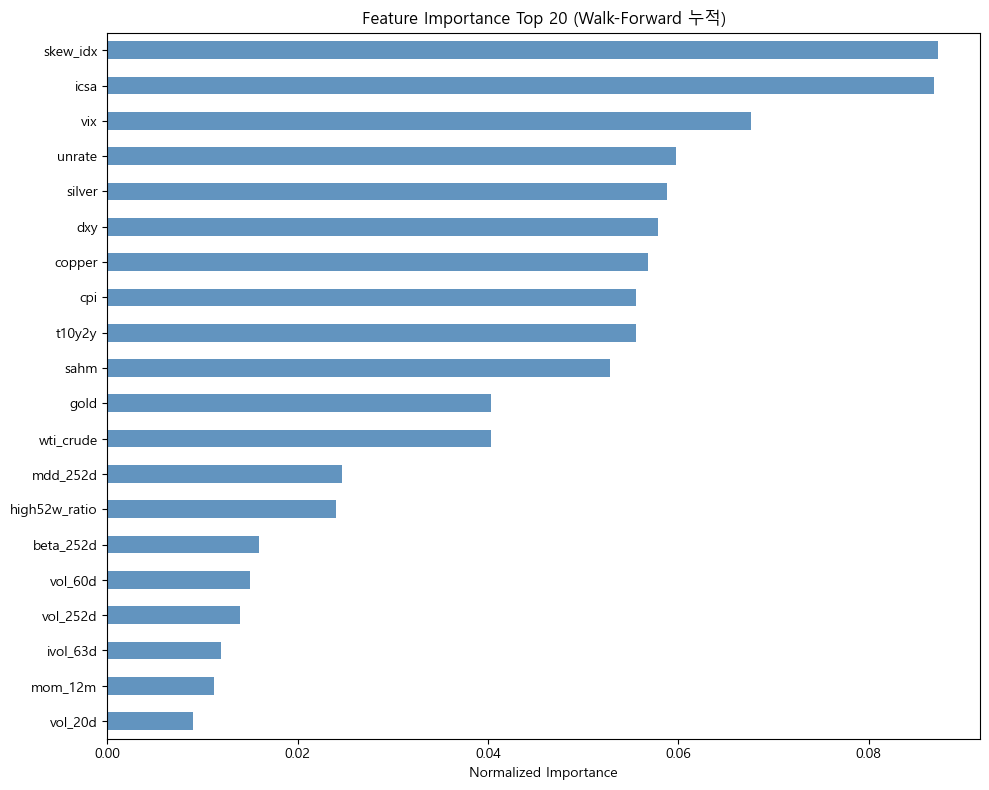

Top 10 피처:
skew_idx    0.0873
icsa        0.0868
vix         0.0676
unrate      0.0597
silver      0.0588
dxy         0.0579
copper      0.0568
cpi         0.0555
t10y2y      0.0555
sahm        0.0528
dtype: float64


In [10]:
feat_norm = feat_imp_sum / feat_imp_sum.sum()
top20     = feat_norm.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance Top 20 (Walk-Forward 누적)')
ax.set_xlabel('Normalized Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 피처:')
print(top20.head(10).round(4))

---
## Section 6. Q & Omega 생성 (Black-Litterman용)

| 변수 | 의미 |
|---|---|
| **Q** | 각 종목의 예측 초과수익률 벡터 (analyst views) |
| **Omega** | 예측 불확실성 — OOS 잔차 분산 대각행렬 |

In [11]:
oos_df

,ticker,gics_sector,fwd_excess_ret_1m,pred
date,,,,
2011-01-31,DVA,Health Care,0.092079,0.049721
2011-01-31,IBM,Information Technology,-0.007444,0.049678
2011-01-31,KMB,Consumer Staples,0.006435,0.049721
2011-01-31,HAS,Consumer Discretionary,0.020640,0.050279
2011-01-31,TER,Information Technology,0.116307,0.047647
...,...,...,...,...
2025-11-30,NCLH,Consumer Discretionary,0.210851,0.013301
2025-11-30,MCO,Financials,0.046670,0.013301
2025-11-30,AOS,Industrials,0.022466,0.013301


In [12]:
# 가장 최근 날짜의 cross-section → Q
last_date = oos_df.index.max()
last_cs   = oos_df.loc[last_date]

if isinstance(last_cs, pd.Series):
    last_cs = last_cs.to_frame().T

Q = last_cs.set_index('ticker')['pred'].rename('Q')

# Omega: 종목별 OOS 잔차 분산
oos_df['resid']  = oos_df[TARGET] - oos_df['pred']
omega_diag       = oos_df.groupby('ticker')['resid'].var().rename('omega')

print(f'Q 벡터: {len(Q)}종목  (기준일: {last_date.date()})')
print(f'\n예측 수익률 상위 10:')
print(Q.nlargest(10).round(4).to_frame())
print(f'\n예측 수익률 하위 10:')
print(Q.nsmallest(10).round(4).to_frame())
print(f'\nOmega 평균: {omega_diag.mean():.6f}')

Q 벡터: 491종목  (기준일: 2025-11-30)

예측 수익률 상위 10:
             Q
ticker        
MDT     0.0133
BF-B    0.0133
ADM     0.0133
ALB     0.0133
LYV     0.0133
NI      0.0133
SJM     0.0133
IDXX    0.0133
FOX     0.0133
AMZN    0.0133

예측 수익률 하위 10:
             Q
ticker        
MDT     0.0133
BF-B    0.0133
ADM     0.0133
ALB     0.0133
LYV     0.0133
NI      0.0133
SJM     0.0133
IDXX    0.0133
FOX     0.0133
AMZN    0.0133

Omega 평균: 0.007809


In [13]:
results = {
    'oos_df'    : oos_df,
    'metrics'   : metrics_df,
    'ic_ts'     : ic_ts,
    'feat_imp'  : feat_norm,
    'Q'         : Q,
    'omega'     : omega_diag,
    'ALL_FEATS' : ALL_FEATS,
}
with open(OUTPUT_DIR / 'xgb_results.pkl', 'wb') as f:
    pickle.dump(results, f)

oos_df.to_csv(OUTPUT_DIR / 'oos_predictions.csv')
metrics_df.to_csv(OUTPUT_DIR / 'fold_metrics.csv')
Q.to_csv(OUTPUT_DIR / 'Q_views.csv')
omega_diag.to_csv(OUTPUT_DIR / 'omega_diag.csv')

print('저장 완료:')
for f in OUTPUT_DIR.iterdir():
    print(f'  {f.name}')

저장 완료:
  fold_metrics.csv
  omega_diag.csv
  oos_predictions.csv
  Q_views.csv
  xgb_feature_importance.png
  xgb_IC_analysis.png
  xgb_results.pkl
